## Пример решения задачи регрессии

In [2]:
import torch
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [1]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (13.0, 5.0) # Установка размера графика 13 х 5

# Обучающая выборка (Train dataset)

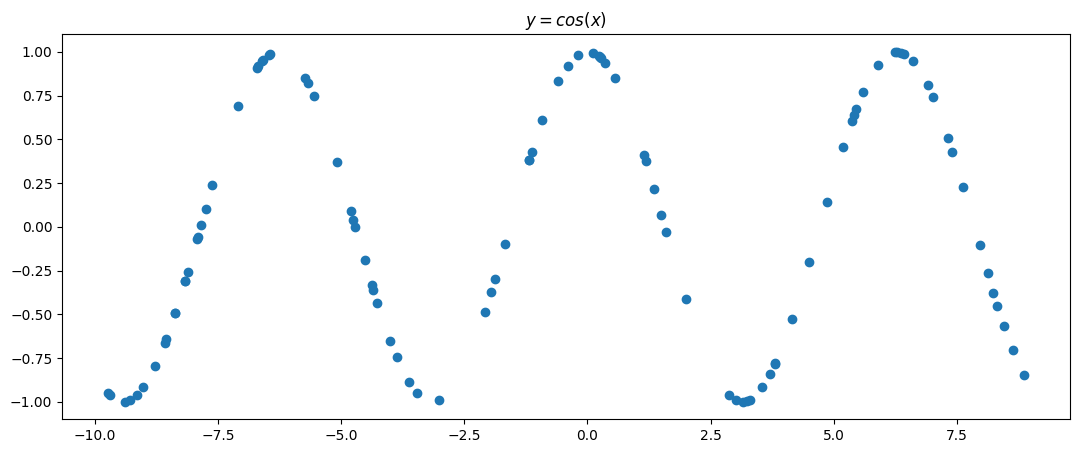

In [21]:
x_train = torch.rand(100) # 100 случайных чисел от 0 до 1
x_train = x_train * 20.0 - 10.0 # растягиваем значения от -10 до 10

y_train = torch.cos(x_train)

plt.plot(x_train.numpy(), y_train.numpy(), 'o')
plt.title('$y = cos(x)$');

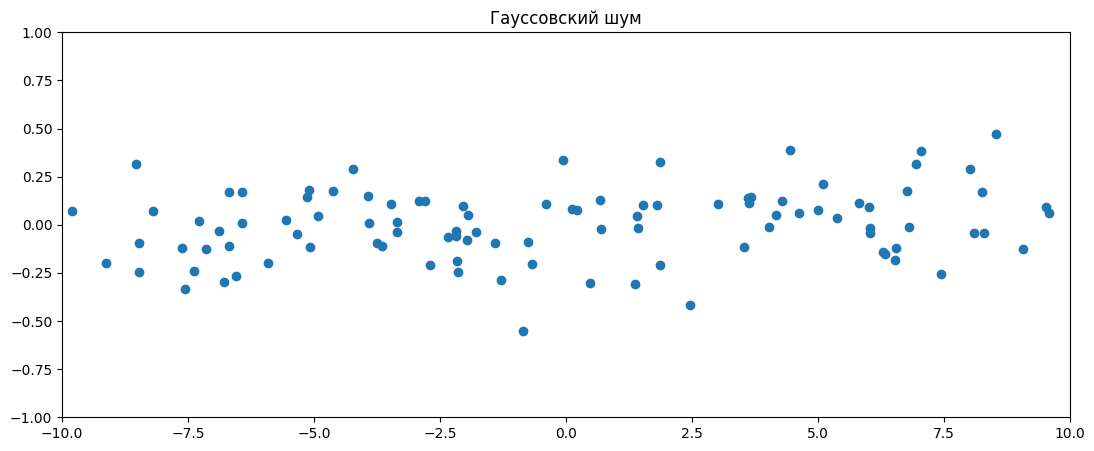

In [4]:
noise = torch.randn(y_train.shape) / 5.

plt.plot(x_train.numpy(), noise.numpy(), 'o')
plt.axis([-10, 10, -1, 1])
plt.title('Гауссовский шум');

Text(0, 0.5, 'y_train')

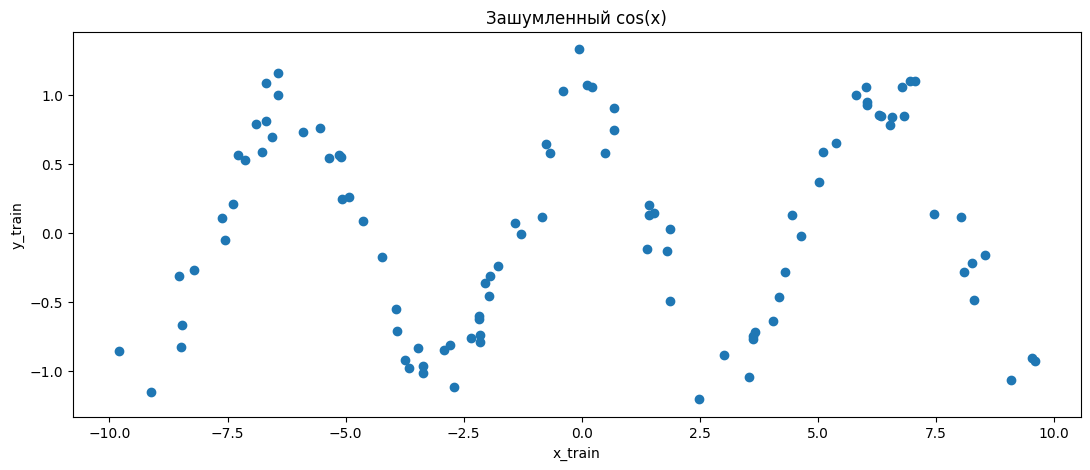

In [5]:
y_train = y_train + noise
plt.plot(x_train.numpy(), y_train.numpy(), 'o')
plt.title('Зашумленный cos(x)')
plt.xlabel('x_train')
plt.ylabel('y_train')

In [34]:
x_train.unsqueeze_(1)
y_train.unsqueeze_(1);

In [35]:
#пример unsqueeze
tmp = torch.Tensor([1,2,3])
print(tmp)
print(tmp.unsqueeze(1))

tensor([1., 2., 3.])
tensor([[1.],
        [2.],
        [3.]])


# Контрольная выборка (Validation dataset)

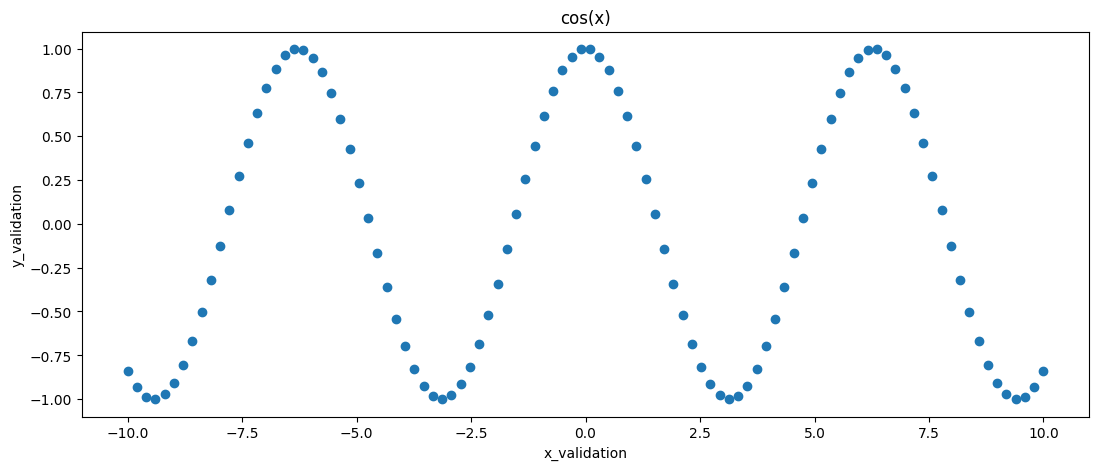

In [37]:
x_validation = torch.linspace(-10, 10, 100)
y_validation = torch.cos(x_validation.data)
plt.plot(x_validation.numpy(), y_validation.numpy(), 'o')
plt.title('cos(x)')
plt.xlabel('x_validation')
plt.ylabel('y_validation');

In [9]:
x_validation.unsqueeze_(1)
y_validation.unsqueeze_(1);

# Построение модели

In [10]:
class RegNet(torch.nn.Module):
    def __init__(self, n_hidden_neurons):
        super(RegNet, self).__init__()
        self.fc1 = torch.nn.Linear(1, n_hidden_neurons)
        self.act1 = torch.nn.Tanh()
        self.fc2 = torch.nn.Linear(n_hidden_neurons, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act1(x)
        x = self.fc2(x)
        return x

cos_net = RegNet(6)

## Прогнозирование (Prediction)

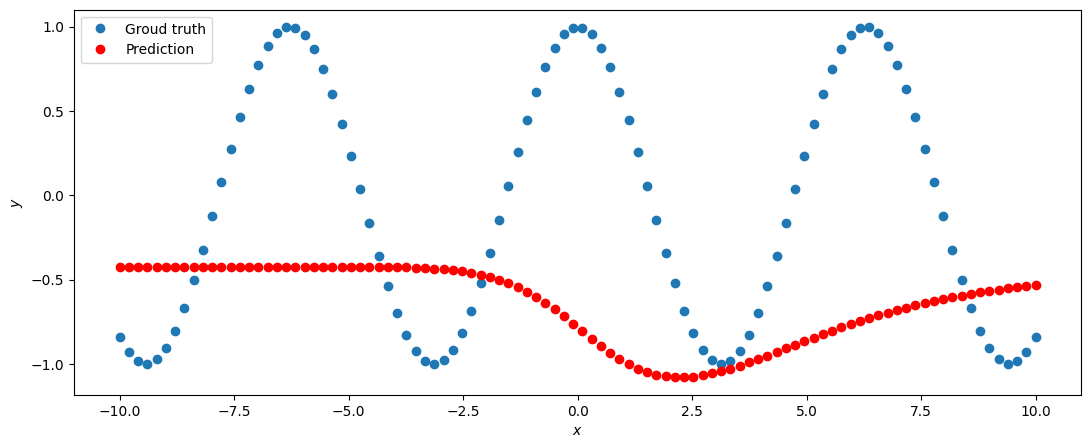

In [12]:
def predict(net, x, y):
    y_pred = net.forward(x)

    plt.plot(x.numpy(), y.numpy(), 'o', label='Groud truth')
    plt.plot(x.numpy(), y_pred.data.numpy(), 'o', c='r', label='Prediction');
    plt.legend(loc='upper left')
    plt.xlabel('$x$')
    plt.ylabel('$y$')

predict(cos_net, x_validation, y_validation)

## Функция ошибки (или потерь) (Loss function)

In [13]:
def loss(pred, target):
    squares = (pred - target) ** 2
    return squares.mean()

## Алгоритм минимизации ошибки

In [17]:
optimizer = torch.optim.Adam(cos_net.parameters(), lr=0.01)
print(list(cos_net.parameters()))

[Parameter containing:
tensor([[-0.2366],
        [-0.4817],
        [ 0.2650],
        [ 0.5696],
        [ 0.0577],
        [-0.0848]], requires_grad=True), Parameter containing:
tensor([ 0.9294, -0.0346, -0.9457, -0.1891, -0.2354, -0.5631],
       requires_grad=True), Parameter containing:
tensor([[-0.2970,  0.2322,  0.1546, -0.3042,  0.2621,  0.1358]],
       requires_grad=True), Parameter containing:
tensor([-0.3713], requires_grad=True)]


## Обучение модели

tensor(0.8727, grad_fn=<MeanBackward0>)
tensor(0.5210, grad_fn=<MeanBackward0>)
tensor(0.4278, grad_fn=<MeanBackward0>)
tensor(0.3564, grad_fn=<MeanBackward0>)
tensor(0.2688, grad_fn=<MeanBackward0>)
tensor(0.2030, grad_fn=<MeanBackward0>)
tensor(0.1776, grad_fn=<MeanBackward0>)
tensor(0.1266, grad_fn=<MeanBackward0>)
tensor(0.0678, grad_fn=<MeanBackward0>)
tensor(0.0270, grad_fn=<MeanBackward0>)
tensor(0.0142, grad_fn=<MeanBackward0>)
tensor(0.0114, grad_fn=<MeanBackward0>)
tensor(0.0107, grad_fn=<MeanBackward0>)
tensor(0.0108, grad_fn=<MeanBackward0>)
tensor(0.0109, grad_fn=<MeanBackward0>)
tensor(0.0110, grad_fn=<MeanBackward0>)
tensor(0.0110, grad_fn=<MeanBackward0>)
tensor(0.0110, grad_fn=<MeanBackward0>)
tensor(0.0110, grad_fn=<MeanBackward0>)
tensor(0.0107, grad_fn=<MeanBackward0>)
tensor(0.0108, grad_fn=<MeanBackward0>)
tensor(0.0117, grad_fn=<MeanBackward0>)
tensor(0.0106, grad_fn=<MeanBackward0>)
tensor(0.0105, grad_fn=<MeanBackward0>)
tensor(0.0104, grad_fn=<MeanBackward0>)


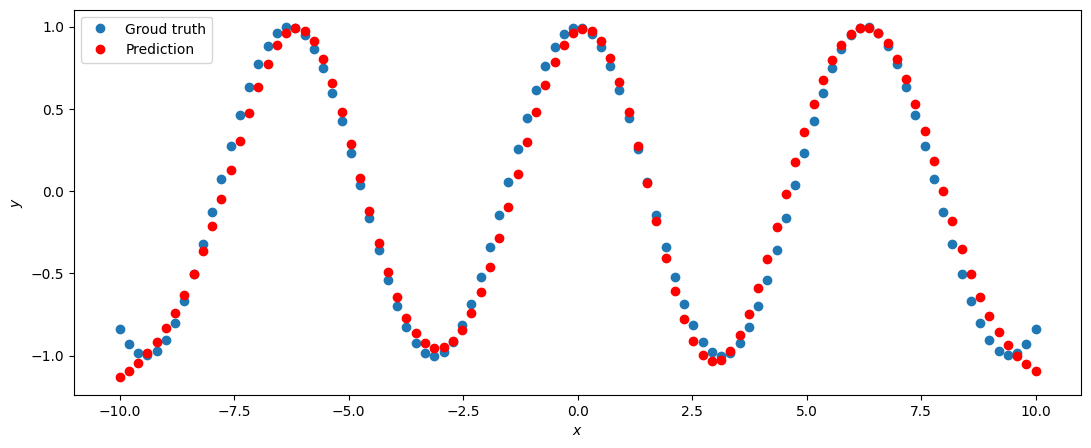

In [18]:
for epoch_index in range(4000):
    optimizer.zero_grad()

    y_pred = cos_net.forward(x_train)
    loss_val = loss(y_pred, y_train)

    loss_val.backward()

    optimizer.step()
    
    if epoch_index%100==0:
        print(loss(cos_net.forward(x_validation),y_validation))

predict(cos_net, x_validation, y_validation)